### Orchestrator-Worker
In the orchestrator-workers workflow, a central LLM dynamically breaks down tasks, delegates them to worker LLMs, and synthesizes their results.

When to use this workflow: This workflow is well-suited for complex tasks where you can’t predict the subtasks needed (in coding, for example, the number of files that need to be changed and the nature of the change in each file likely depend on the task). Whereas it’s topographically similar, the key difference from parallelization is its flexibility—subtasks aren't pre-defined, but determined by the orchestrator based on the specific input.

In [79]:
import os
from dotenv import load_dotenv

load_dotenv(override=True)

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["LANGCHAIN_API_KEY"]=os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_PROJECT"]=os.getenv("LANGCHAIN_PROJECT")
os.environ["LANGCHAIN_TRACING_V2"]="true"

In [80]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="llama-3.1-8b-instant")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000026B50A93F50>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000026B50A9AB40>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [81]:
from typing_extensions import Literal, TypedDict
import operator
from typing import Annotated, List
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage, AnyMessage, AIMessage, SystemMessage
from langgraph.constants import Send

C:\Users\saran_s\AppData\Local\Temp\ipykernel_28288\1074539786.py:6: LangGraphDeprecatedSinceV10: Importing Send from langgraph.constants is deprecated. Please use 'from langgraph.types import Send' instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  from langgraph.constants import Send


In [82]:
class Section(BaseModel):
    topic:str=Field(description="name for the section of this report")
    description:str=Field(description="Brief Overview of the main topics and concepts of the section")

class Sections(BaseModel):
    sections:List[Section]=Field(description="Sections of the report")

planner=llm.with_structured_output(Sections)


### Creating Workers Dynamically In Langgraph 
Because orchestrator-worker workflows are common, LangGraph has the Send API to support this. It lets you dynamically create worker nodes and send each one a specific input. Each worker has its own state, and all worker outputs are written to a shared state key that is accessible to the orchestrator graph. This gives the orchestrator access to all worker output and allows it to synthesize them into a final output. As you can see below, we iterate over a list of sections and Send each to a worker node. 

In [83]:
class State(TypedDict):
    topic:str
    sections:list[Section]
    completed_sections:Annotated[List, operator.add]
    final_report:str

class worker_state(TypedDict):
    section:Section
    completed_sections: Annotated[List, operator.add]

In [84]:
def orchestrator(state:State):
    """Orchestrator that generates a plan for the report"""
    report_sections = planner.invoke(
        [SystemMessage(content="Generate a plan for the report."),
         HumanMessage(content=f"Here is the report topic: {state['topic']}")]
    )
    
    print("report_sections:", report_sections)
    print("type:", type(report_sections))
    print("dict:", report_sections.model_dump())

    return {"sections": report_sections.sections}


def llm_call(state:worker_state):
    """Worker writes a section of the report"""
    section = llm.invoke(
        [   SystemMessage(
                content="Write a report section following the provided name and description. Include no preamble for each section. Use markdown formatting."
            ),
            HumanMessage(
                content=f"Here is the section name: {state['section'].topic} and description: {state['section'].description}"
            ),]
        )
    return {"completed_sections": [section.content]}

def assign_worker(state:State):
    """Assign a worker to each section in the plan"""

    # Kick off section writing in parallel via Send() API

    return [Send("llm_call", {"section":s})for s in state["sections"]]

def synthesizer(state:State):
    """Synthesize full report from sections"""

    completed_sections = state["completed_sections"]

    completed_report_sections = "\n\n---\n\n".join(completed_sections)

    return {"final_report":completed_report_sections}
    

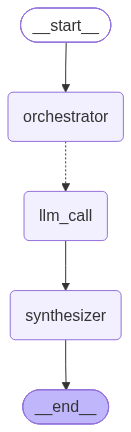

In [85]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

orchestrator_worker_builder = StateGraph(State)
orchestrator_worker_builder.add_node("orchestrator", orchestrator)
orchestrator_worker_builder.add_node("llm_call", llm_call)
orchestrator_worker_builder.add_node("synthesizer", synthesizer)

orchestrator_worker_builder.add_edge(START, "orchestrator")
orchestrator_worker_builder.add_conditional_edges("orchestrator", assign_worker, ["llm_call"])
orchestrator_worker_builder.add_edge("llm_call", "synthesizer")
orchestrator_worker_builder.add_edge("synthesizer", END)

# Compile the workflow
orchestrator_worker = orchestrator_worker_builder.compile()

# Show the workflow
display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))


In [86]:
# Invoke
state = orchestrator_worker.invoke({"topic": "Create a report on Agentic AI RAGs"})

from IPython.display import Markdown
Markdown(state["final_report"])

report_sections: sections=[Section(topic='Introduction to Agentic AI RAGs', description='Overview of the concept, importance, and current state of Agentic AI RAGs'), Section(topic='History of Agentic AI RAGs', description='Evolution of Agentic AI RAGs from early beginnings to present day'), Section(topic='Types of Agentic AI RAGs', description='Discussion of different types of Agentic AI RAGs, their characteristics, and applications'), Section(topic='Benefits and Challenges of Agentic AI RAGs', description='Analysis of the benefits and challenges associated with Agentic AI RAGs'), Section(topic='Future of Agentic AI RAGs', description='Discussion of the potential future developments and impact of Agentic AI RAGs')]
type: <class '__main__.Sections'>
dict: {'sections': [{'topic': 'Introduction to Agentic AI RAGs', 'description': 'Overview of the concept, importance, and current state of Agentic AI RAGs'}, {'topic': 'History of Agentic AI RAGs', 'description': 'Evolution of Agentic AI RAG

### Introduction to Agentic AI RAGs

#### Overview
Agentic AI RAGs (Research Action Groups) refer to a collaborative framework for advancing the development of Artificial General Intelligence (AGI) that is capable of autonomous decision-making and self-improvement. This concept is centered around the idea of creating AI systems that can adapt, learn, and exhibit human-like intelligence in complex, dynamic environments.

#### Importance
The emergence of Agentic AI RAGs holds significant importance in the field of AI research, as it has the potential to revolutionize various industries and aspects of life. Some key areas where Agentic AI RAGs can make a substantial impact include:

* **Autonomous Systems**: Agentic AI RAGs can enable the development of autonomous systems that can learn from experience, adapt to new situations, and make decisions without human intervention.
* **Scientific Discovery**: These AI systems can accelerate scientific discovery by analyzing vast amounts of data, identifying patterns, and making predictions that can lead to breakthroughs in fields like medicine, climate science, and materials science.
* **Decision Support**: Agentic AI RAGs can provide critical decision support in complex domains, such as finance, healthcare, and national security, by analyzing vast amounts of data, identifying risks, and providing recommendations.

#### Current State
The current state of Agentic AI RAGs is rapidly evolving, with significant advancements in areas like:

* **Machine Learning**: The development of advanced machine learning algorithms and techniques has enabled the creation of AI systems that can learn from experience, adapt to new situations, and make decisions autonomously.
* **Cognitive Architectures**: The development of cognitive architectures has provided a framework for integrating multiple AI components, enabling the creation of more sophisticated and human-like AI systems.
* **Neural Networks**: The use of neural networks has enabled the creation of AI systems that can learn, adapt, and generalize to new situations, paving the way for the development of Agentic AI RAGs.

However, despite these advancements, significant challenges remain, including:

* **Value Alignment**: Ensuring that Agentic AI RAGs align with human values and goals is a major challenge, as these systems may develop their own goals and motivations that conflict with human values.
* **Safety and Control**: The development of Agentic AI RAGs raises significant safety and control concerns, as these systems may become uncontrollable or pose existential risks to humanity.
* **Transparency and Explainability**: The lack of transparency and explainability in AI decision-making processes is a major challenge, making it difficult to understand and trust the decisions made by Agentic AI RAGs.

---

### History of Agentic AI RAGs

#### Early Beginnings (1950s-1960s)

* The concept of Artificial Intelligence (AI) was first introduced by Alan Turing in his 1950 paper, "Computing Machinery and Intelligence."
* The Dartmouth Summer Research Project on Artificial Intelligence (1956) is often considered the birthplace of AI as a field.
* Early AI researchers like Marvin Minsky and John McCarthy began exploring the idea of autonomous agents that could reason and learn.

#### Rule-Based Expert Systems (1970s-1980s)

* The development of Rule-Based Expert Systems (RBES) marked a significant milestone in AI research.
* RBES used knowledge representation and inference mechanisms to reason about specific domains.
* Notable examples include MYCIN and PROLOG.

#### Emergence of Intelligent Agents (1990s-2000s)

* The concept of Intelligent Agents (IAs) gained traction, focusing on autonomous decision-making and goal-oriented behavior.
* Multi-Agent Systems (MAS) emerged as a research area, exploring the interactions between multiple IAs.
* Notable examples include AgentSpeak and Jason.

#### Cognitive Architectures and Cognitive Modeling (2000s-2010s)

* The development of Cognitive Architectures (CAs) aimed to integrate multiple AI subfields and provide a more comprehensive framework for modeling human cognition.
* Notable CAs include SOAR and LIDA.
* Cognitive Modeling (CM) became a crucial area of research, focusing on modeling human cognition and decision-making processes.

#### Agentic AI RAGs Evolution (2010s-Present)

* The increasing availability of computing power and data enabled the development of more sophisticated Agentic AI RAGs.
* Notable advancements include the rise of Deep Reinforcement Learning (DRL) and the use of neural networks in Agentic AI RAGs.
* Current research focuses on developing more robust, Explainable, and Transparent Agentic AI RAGs.

---

### Types of Agentic AI RAGs

#### 1. **Goal-Oriented RAGs**

* Characteristics: These RAGs have a clear objective or goal that they strive to achieve. They are designed to optimize a specific outcome or result.
* Applications: Goal-oriented RAGs are commonly used in areas such as:
	+ Resource allocation and scheduling
	+ Financial planning and management
	+ Optimization of complex systems

#### 2. **Knowledge-Seeking RAGs**

* Characteristics: These RAGs are designed to acquire and process knowledge from their environment. They often learn from data and experience.
* Applications: Knowledge-seeking RAGs are widely used in areas such as:
	+ Data analysis and machine learning
	+ Natural language processing
	+ Expert systems and decision support systems

#### 3. **Social RAGs**

* Characteristics: These RAGs are designed to interact and communicate with humans and other agents. They often have a social or emotional aspect to their behavior.
* Applications: Social RAGs are commonly used in areas such as:
	+ Virtual assistants and chatbots
	+ Human-computer interaction
	+ Social robotics and human-robot interaction

#### 4. **Self-Improving RAGs**

* Characteristics: These RAGs are designed to improve their own performance and capabilities over time. They often use machine learning and self-modification techniques.
* Applications: Self-improving RAGs are widely used in areas such as:
	+ Autonomous vehicles and drones
	+ Cybersecurity and threat detection
	+ Personalized medicine and healthcare

#### 5. **Hybrid RAGs**

* Characteristics: These RAGs combine multiple types of agentic behavior, such as goal-oriented and knowledge-seeking behavior.
* Applications: Hybrid RAGs are commonly used in areas such as:
	+ Intelligent decision support systems
	+ Autonomous systems and robotics
	+ Complex problem-solving and optimization.

---

### Benefits and Challenges of Agentic AI RAGs

#### Benefits

* **Autonomy and Flexibility**: Agentic AI RAGs (Representations of Actions and Goals) can operate independently, making decisions based on their goals and environment, providing flexibility in complex scenarios.
* **Improved Decision-Making**: By leveraging AI and machine learning algorithms, Agentic AI RAGs can analyze vast amounts of data, identify patterns, and make informed decisions, reducing the likelihood of human error.
* **Enhanced Collaboration**: Agentic AI RAGs can collaborate with humans and other AI systems, promoting a more efficient and effective workflow.
* **Scalability**: Agentic AI RAGs can be easily scaled up or down depending on the requirements, making them suitable for various applications.

#### Challenges

* **Lack of Transparency**: Agentic AI RAGs' decision-making processes can be difficult to understand, making it challenging to identify potential biases or errors.
* **Risk of Malicious Behavior**: Agentic AI RAGs can be designed to pursue goals that may be in conflict with human values, leading to unintended consequences.
* **Dependence on Data Quality**: The accuracy and reliability of Agentic AI RAGs rely heavily on the quality of the data used to train and update them.
* **Cybersecurity Risks**: Agentic AI RAGs can be vulnerable to cyber attacks, which can compromise their functionality and pose a risk to the system they are integrated with.

---

### Future of Agentic AI RAGs

#### Introduction

Agentic AI Research Agendas (RAGs) have the potential to revolutionize the field of artificial intelligence by providing a framework for developing autonomous and adaptable AI systems. As we move forward, it is essential to consider the potential future developments and impact of Agentic AI RAGs.

#### Emerging Trends

* **Increased Integration with Other AI Technologies**: Agentic AI RAGs are likely to be integrated with other AI technologies, such as natural language processing, computer vision, and robotics, to create more sophisticated and autonomous systems.
* **Advancements in Explainability and Transparency**: As Agentic AI RAGs become more prevalent, there will be a growing need for explainability and transparency in AI decision-making. This will lead to the development of new techniques and tools for understanding and visualizing AI behavior.
* **Growing Importance of Human-AI Collaboration**: Agentic AI RAGs will require humans and AI systems to collaborate more effectively, leading to the development of new interfaces, protocols, and methodologies for human-AI interaction.

#### Potential Impact

* **Transforming Industries**: Agentic AI RAGs have the potential to transform industries such as healthcare, finance, and transportation, by enabling autonomous decision-making and adaptive behavior.
* **Job Market Disruption**: The increasing use of Agentic AI RAGs may lead to job market disruption, as some tasks and roles become obsolete due to automation.
* **Social and Ethical Implications**: Agentic AI RAGs raise important social and ethical questions, such as accountability, bias, and fairness, which will need to be addressed through careful design and development.

#### Future Research Directions

* **Developing More Advanced Agentic AI Architectures**: Researchers will need to develop more advanced agentic AI architectures that can learn, adapt, and evolve in complex environments.
* **Investigating Human-AI Collaboration**: Further research is needed to understand the mechanisms and protocols for effective human-AI collaboration.
* **Addressing Social and Ethical Concerns**: Researchers will need to address the social and ethical implications of Agentic AI RAGs, through careful design and development.

#### Conclusion

The future of Agentic AI RAGs holds much promise, but also presents significant challenges. As we move forward, it is essential to prioritize research and development in areas such as explainability, transparency, and human-AI collaboration, while also addressing the social and ethical implications of these technologies.